In [20]:
import tensorflow as tf
mnist=tf.keras.datasets.mnist      #Toy Dataset from Keras

In [21]:
(x_train,y_train),(x_test,y_test)=mnist.load_data()       #Loading the dataset

In [22]:
x_train.shape        #x_train contains 60,000 images, each being a 28x28 pixel grayscale image from the MNIST dataset.

(60000, 28, 28)

In [23]:
x_train,x_test=x_train/255.0,x_test/255.0     #Scaling the values to (0,1)

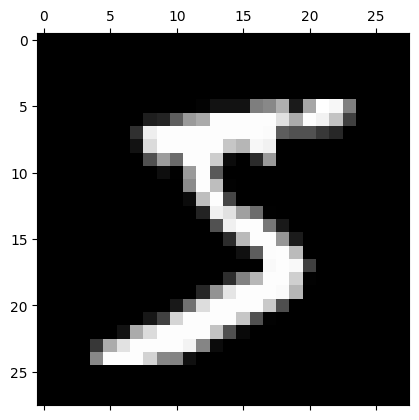

In [24]:
import matplotlib.pyplot as plt
plt.matshow(x_train[0],cmap='gray')           # This function is used to display a matrix (in this case, x_train[0], which is the first 28x28 pixel image from your training dataset) as an image. It will render the numerical pixel values as a grayscale image, allowing you to visualize the first handwritten digit.

In [26]:
model=tf.keras.models.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28)),
    tf.keras.layers.Dense(128,activation='relu'),
    tf.keras.layers.Dropout(0.2),
    tf.keras.layers.Dense(10,activation='softmax')
])
#This code defines a Sequential Keras model, which is a linear stack of layers, commonly used for building neural networks. Let's break down each layer:

#tf.keras.layers.Flatten(input_shape=(28,28)): This is the input layer. It takes the 28x28 pixel 2D images and flattens them into a 1D array of 784 pixels. This is necessary because the subsequent Dense layers expect 1D inputs.

#tf.keras.layers.Dense(128, activation='relu'): This is a fully connected (dense) hidden layer with 128 neurons. The relu (Rectified Linear Unit) activation function is applied to the output of these neurons, introducing non-linearity into the model.

#tf.keras.layers.Dropout(0.2): This layer is a regularization technique. During training, it randomly sets 20% of the input units to zero at each update. This helps prevent the model from overfitting to the training data by making the network more robust.

#tf.keras.layers.Dense(10, activation='softmax'): This is the output layer. It has 10 neurons, one for each possible digit (0 through 9). The softmax activation function converts the raw outputs (logits) into probabilities, where the sum of all 10 probabilities equals 1. The neuron with the highest probability indicates the model's predicted digit.


/usr/local/lib/python3.13/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [27]:
model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'],)
model.summary()


#This code block performs two key actions for your neural network model:

#1)model.compile(...): This line configures the model for training. You specify:

   #optimizer='adam': This is the algorithm used to adjust the model's internal parameters (weights) during training to minimize the loss. Adam is a popular and effective optimization algorithm.

   #loss='sparse_categorical_crossentropy': This is the loss function the model will try to minimize. It's suitable for classification problems where you have integer labels (like digits 0-9) and multiple output classes. It measures how well the model's predicted probability distribution matches the true distribution.

   #metrics=['accuracy']: These are the metrics used to evaluate the model's performance during training and testing. In this case, 'accuracy' will track the proportion of correctly classified samples.

#2)model.summary(): This command prints a summary of your model's architecture. It shows each layer in the model, its output shape, and the number of trainable parameters (weights and biases) in each layer, as well as the total parameters in the entire model. This is very useful for understanding the structure and complexity of your network.

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 101,770 (397.54 KB)

 Trainable params: 101,770 (397.54 KB)

 Non-trainable params: 0 (0.00 B)

In [28]:
r=model.fit(x_train,y_train,validation_data=(x_test,y_test),epochs=10,verbose=2)



#This code line r = model.fit(...) is where the neural network model is actually trained. Let's break down its components:

  #model.fit(...): This function initiates the training process for your Keras model.

  #x_train, y_train: These are your training data and their corresponding labels. The model learns from these examples.

  #validation_data=(x_test,y_test): This provides a separate dataset (x_test for features, y_test for labels) that the model will evaluate at the end of each training epoch. This helps you monitor the model's performance on unseen data and detect overfitting.

  #epochs=10: An epoch is one complete pass through the entire training dataset. Here, the model will be trained for 10 full passes over x_train.

  #verbose=2: This controls the verbosity of the output during training. verbose=2 means that for each epoch, it will print one line summarizing the epoch's results (e.g., loss, accuracy for both training and validation sets).

  #r = ...: The model.fit method returns a History object (stored in the variable r), which contains a record of training loss values and metrics (like accuracy) at successive epochs, for both the training and validation data. This History object is often used later to plot training progress.

Epoch 1/10
1875/1875 - 8s - 4ms/step - accuracy: 0.9126 - loss: 0.2996 - val_accuracy: 0.9554 - val_loss: 0.1495
Epoch 2/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9562 - loss: 0.1462 - val_accuracy: 0.9680 - val_loss: 0.1041
Epoch 3/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9668 - loss: 0.1102 - val_accuracy: 0.9730 - val_loss: 0.0892
Epoch 4/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9720 - loss: 0.0899 - val_accuracy: 0.9736 - val_loss: 0.0805
Epoch 5/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9759 - loss: 0.0771 - val_accuracy: 0.9781 - val_loss: 0.0734
Epoch 6/10
1875/1875 - 6s - 3ms/step - accuracy: 0.9788 - loss: 0.0674 - val_accuracy: 0.9777 - val_loss: 0.0704
Epoch 7/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9809 - loss: 0.0596 - val_accuracy: 0.9785 - val_loss: 0.0730
Epoch 8/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9821 - loss: 0.0551 - val_accuracy: 0.9796 - val_loss: 0.0687
Epoch 9/10
1875/1875 - 5s - 3ms/step - accuracy: 0.9834 - loss: 0.0506 - val_accuracy: 0.9775 - 

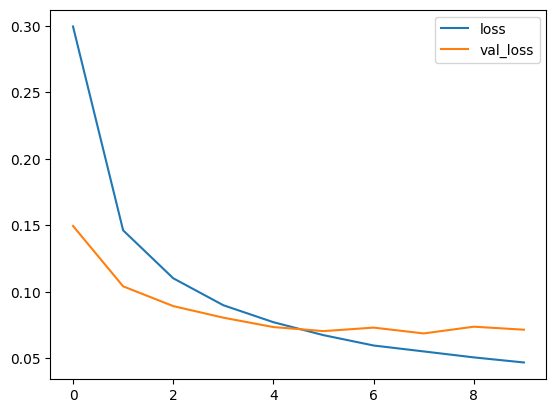

In [29]:
plt.plot(r.history['loss'],label=['loss'])
plt.plot(r.history['val_loss'],label=['val_loss'])
plt.legend()

In [30]:
y_pred=model.predict(x_test)

#The code y_pred = model.predict(x_test) uses your trained neural network model to make predictions on the x_test dataset. The model.predict() method will output the predicted probabilities for each class (digit 0-9) for every image in x_test. The result, y_pred, will be an array where each entry is an array of 10 probabilities, representing the likelihood that a given image belongs to each of the 10 digit classes.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [31]:
import numpy as np

y_pred_labels = np.argmax(y_pred, axis=1)
accuracy = np.mean(y_pred_labels == y_test)
print(f"Test Accuracy: {accuracy*100:.2f}%")

#To check the accuracy of the ANN model, you should compare the predicted class labels (derived from y_pred) with the true labels (y_test). Here's how you can do it:

   #Convert the predicted probabilities in y_pred into concrete class predictions (the digit with the highest probability).
   #Compare these predictions with the actual y_test values.
   #Calculate the overall accuracy.

Test Accuracy: 98.09%
